# Exploratory data analysis and classification modeling for a sales data dataset.
### In this project I'm using a sample of data to show my skills in:

1. Data Exploration: Using my Python skills to tell us more about what’s going on with this data. 
2. Model Building: Using Python to build a model to help us predict when “Delivery Status” = “Late delivery”.
3. Data manipulation, cleanup to make it usable for answering the questions above.


In [1]:
# setup environment section

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
unfi=pd.read_csv('unfi_sample_data_20230721.csv',encoding='latin-1')
#first hurdle :-D there's a different encoding on this file.
display(unfi)

,Type,Days for shipping (real),Benefit per order,Sales per customer,Delivery Status,Category Id,Category Name,Customer City,Customer Country,Customer Email,...,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,CASH,4,-247.779999,309.720001,Shipping on time,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,...,CLOSED,NaN,1360,73,NaN,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
1,PAYMENT,2,134.210007,298.250000,Advance shipping,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,...,PENDING_PAYMENT,NaN,1360,73,NaN,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
2,TRANSFER,2,68.430000,285.140015,Late delivery,73,Sporting Goods,Miami,EE. UU.,XXXXXXXXX,...,PROCESSING,NaN,1360,73,NaN,Smart watch,327.750000,0,1/15/2018 10:21,First Class
3,CASH,3,133.720001,278.589996,Late delivery,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,...,CLOSED,NaN,1360,73,NaN,Smart watch,327.750000,0,1/16/2018 10:00,Second Class
4,TRANSFER,6,130.580002,272.029999,Shipping canceled,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,...,SUSPECTED_FRAUD,NaN,1360,73,NaN,Smart watch,327.750000,0,1/19/2018 9:18,Second Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40582,PAYMENT,2,23.809999,377.980011,Advance shipping,45,Fishing,Vista,EE. UU.,XXXXXXXXX,...,PENDING_PAYMENT,NaN,1004,45,NaN,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 15:14,Standard Class
40583,PAYMENT,2,125.730003,371.980011,Advance shipping,45,Fishing,Vista,EE. UU.,XXXXXXXXX,...,PENDING_PAYMENT,NaN,1004,45,NaN,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 15:14,Standard Class
40584,CASH,3,32.029999,363.980011,Advance shipping,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,...,CLOSED,NaN,1004,45,NaN,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 13:49,Standard Class
40585,PAYMENT,3,165.990005,331.980011,Advance shipping,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,...,PENDING_PAYMENT,NaN,1004,45,NaN,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 6:49,Standard Class


Initially looks like order/sales data. 
Let's take a look at:

1.Missing data?

In [3]:
#missing data ?
unfi.isna().sum()

Type                              0
Days for shipping (real)          0
Benefit per order                 0
Sales per customer                0
Delivery Status                   0
Category Id                       0
Category Name                     0
Customer City                     0
Customer Country                  0
Customer Email                    0
Customer Fname                    0
Customer Id                       0
Customer Lname                    1
Customer Password                 0
Customer Segment                  0
Customer State                    0
Customer Street                   0
Customer Zipcode                  0
Department Id                     0
Department Name                   0
Latitude                          0
Longitude                         0
Market                            0
Order City                        0
Order Country                     0
Order Customer Id                 0
order date (DateOrders)           0
Order Id                    

Looks like we have order zipcodes and product description as the most empty. Can order zipcode be left empty as its the same as order customer zipcode? Is the product description explainable by product name and product card ID? 
First need to check the data types.

In [4]:
print(unfi.dtypes)

Type                           object
Days for shipping (real)        int64
Benefit per order             float64
Sales per customer            float64
Delivery Status                object
Category Id                     int64
Category Name                  object
Customer City                  object
Customer Country               object
Customer Email                 object
Customer Fname                 object
Customer Id                     int64
Customer Lname                 object
Customer Password              object
Customer Segment               object
Customer State                 object
Customer Street                object
Customer Zipcode                int64
Department Id                   int64
Department Name                object
Latitude                      float64
Longitude                     float64
Market                         object
Order City                     object
Order Country                  object
Order Customer Id               int64
order date (

### Some data types could be changed.
A lot of 'object' can be converted to strings. 
Date fields to datetime and floats to integers.

In [5]:
unfi[['Type','Delivery Status','Category Name','Customer City','Customer Country','Customer Email','Customer Fname','Customer Lname','Customer Password','Customer Segment','Customer State','Customer Street','Order Region','Order State','Order Status','Product Description','Product Name','Product Status','Shipping Mode']].astype('string')
unfi[['Days for shipping (real)','Order Zipcode']]=unfi[['Days for shipping (real)','Order Zipcode']].apply(pd.to_numeric,errors='coerce').astype('Int64')
unfi[['shipping date (DateOrders)','order date (DateOrders)']]=unfi[['shipping date (DateOrders)','order date (DateOrders)']].apply(pd.to_datetime)
print(unfi.dtypes)

Type                                  object
Days for shipping (real)               Int64
Benefit per order                    float64
Sales per customer                   float64
Delivery Status                       object
Category Id                            int64
Category Name                         object
Customer City                         object
Customer Country                      object
Customer Email                        object
Customer Fname                        object
Customer Id                            int64
Customer Lname                        object
Customer Password                     object
Customer Segment                      object
Customer State                        object
Customer Street                       object
Customer Zipcode                       int64
Department Id                          int64
Department Name                       object
Latitude                             float64
Longitude                            float64
Market    

In [6]:
unfi.isna().sum()

Type                              0
Days for shipping (real)          0
Benefit per order                 0
Sales per customer                0
Delivery Status                   0
Category Id                       0
Category Name                     0
Customer City                     0
Customer Country                  0
Customer Email                    0
Customer Fname                    0
Customer Id                       0
Customer Lname                    1
Customer Password                 0
Customer Segment                  0
Customer State                    0
Customer Street                   0
Customer Zipcode                  0
Department Id                     0
Department Name                   0
Latitude                          0
Longitude                         0
Market                            0
Order City                        0
Order Country                     0
Order Customer Id                 0
order date (DateOrders)           0
Order Id                    

So there's one missing last name and product description is empty and order zipcode is almost empty.
I'll proceed to drop those two columns.

### So at this point I have identified the type of data, datatypes, missing values and made a decision about what to do with them.

Order description was dropped as is completely empty and could be gathered from other fields such as 'Product Name' and 'Product Category Id'. 
Order Zip could be replaced with Customer Zip. The only danger here is if there's a mismatch between Order address (which is not available) and customer address which is available as (street, zipcode,address).


# Exploratory data analysis 

This looks like sales data. I'm curious about :
1. Total sales / year or quarter.
2. Breakdown of late deliveries. (How many, is it related to a particular product or product type/regions).
3. Breakdown of sales profit by product.
4. Sales by customer.


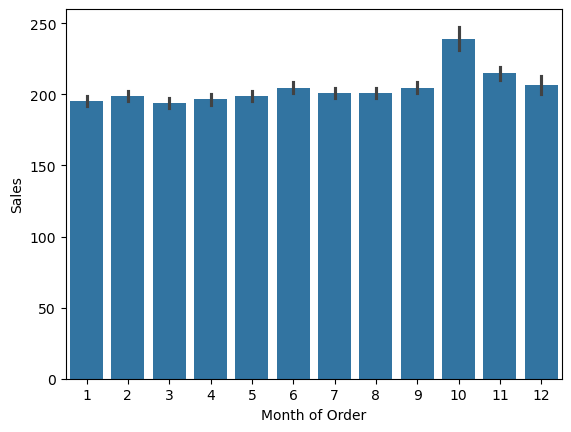

In [7]:
#Total sales per year/ quarter.
unfi_clean=unfi.drop(['Product Description','Order Zipcode'],axis=1)
unfi_clean['Month of Order']=unfi_clean['order date (DateOrders)'].dt.month
unfi_clean['Year of Order']=unfi_clean['order date (DateOrders)'].dt.year

sns.barplot(y='Sales',x='Month of Order',data=unfi_clean)
plt.show()

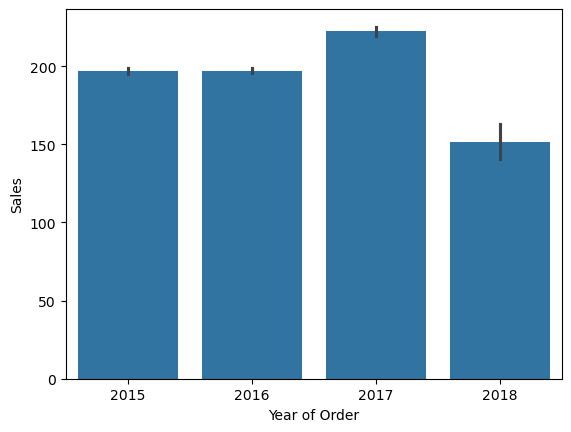

In [8]:
sns.barplot(y='Sales',x='Year of Order',data=unfi_clean)
plt.show()

Delivery Status
Late delivery        22496
Advance shipping      9240
Shipping on time      7092
Shipping canceled     1759
Name: count, dtype: int64


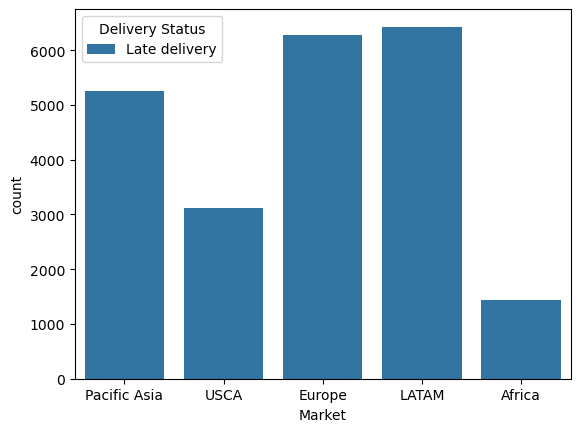

In [9]:
#break down of late deliveries.
# what's the total and trend.
print(unfi_clean['Delivery Status'].value_counts())
late_delivery=unfi_clean[unfi_clean['Delivery Status']=='Late delivery']
sns.countplot(hue='Delivery Status',x='Market',data=late_delivery)
plt.show()

Although the data doesn't reflect port of origin (or from where is the product being shipped). My first flag is as to why Africa will have the lowest amount of late deliveries? I believe this is a reflection as well of the sales volume (less orders , less of them could end up as late deliveries).
Then every other market outside of the USA shows about the similar count of late deliveries.

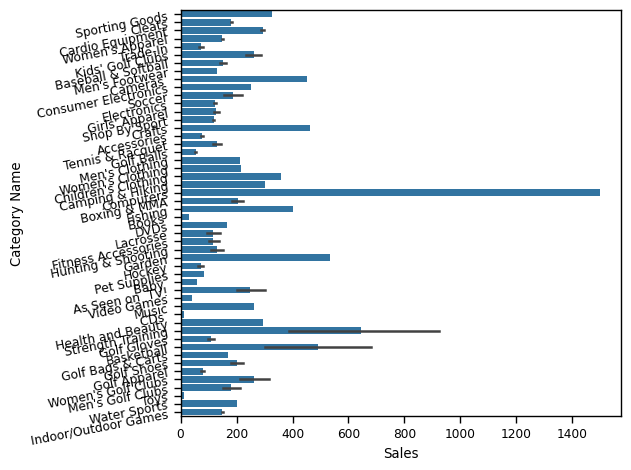

In [10]:
#sales profit by product
sns.set_context("paper")
sns.barplot(y='Category Name',x='Sales',data=unfi_clean,orient='h')
plt.yticks(rotation=11)
plt.tight_layout()
plt.show()

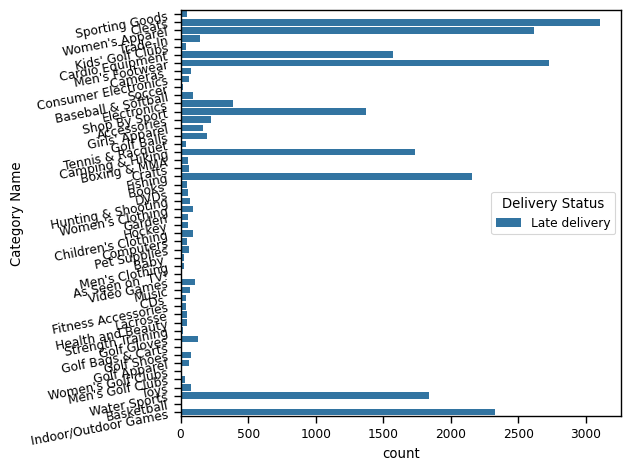

In [11]:
sns.set_context("paper")
sns.countplot(y='Category Name',hue='Delivery Status',data=late_delivery,orient='v')
plt.yticks(rotation=11)
plt.tight_layout()
plt.show()

Low profit and late deliveries are inversely proportional. Go figure X-D.


Let's segment to the USA market


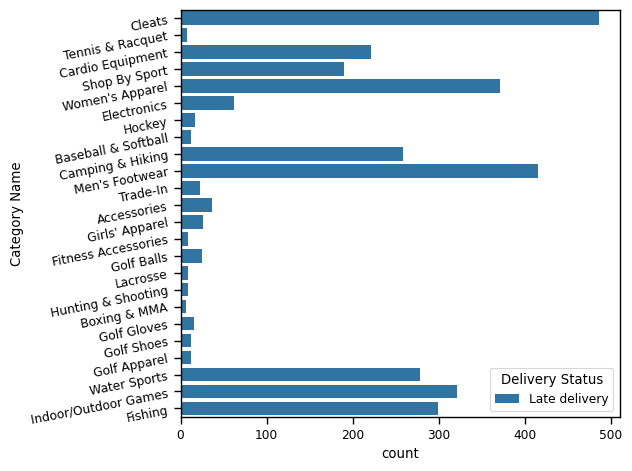

In [12]:
sns.set_context("paper")
sns.countplot(y='Category Name',hue='Delivery Status',data=late_delivery[late_delivery['Market']=='USCA'],orient='v')
plt.yticks(rotation=11)
plt.tight_layout()
plt.show()

Usually outside footwear (cleats / mens ) and water/indoor/outdoor and fishing lead 

In [13]:
# which customers drive sales 
display(unfi_clean[['Sales per customer','Customer Fname','Customer Lname']].sort_values(by='Sales per customer',ascending=True).value_counts())

Sales per customer  Customer Fname  Customer Lname
97.489998           Mary            Smith             49
126.089996          Mary            Smith             47
103.989998          Mary            Smith             45
118.290001          Mary            Smith             44
106.589996          Mary            Smith             41
                                                      ..
1599.989990         Charles         Rogers             1
1639.989990         Mary            Anderson           1
1759.989990         Daniel          Smith              1
1889.989990         Samantha        Smith              1
1899.989990         Mary            Clark              1
Name: count, Length: 35044, dtype: int64

Mary and Samantha have the highest number of sales.

In [14]:
# which products have low profit margins
display(unfi_clean[['Product Name','Order Profit Per Order','Order Item Total']].sort_values(by='Order Profit Per Order',ascending=True).value_counts())

Product Name                             Order Profit Per Order  Order Item Total
Nike Men's CJ Elite 2 TD Football Cleat   61.770000              128.690002          29
                                          56.779999              118.290001          22
                                          46.799999              97.489998           20
                                          44.130001              126.089996          19
                                          61.150002              127.389999          18
                                                                                     ..
Adult dog supplies                       -1.060000               75.959999            1
                                         -1.040000               79.760002            1
                                                                 80.180000            1
                                          0.000000               84.400002            1
insta-bed Neverflat Air Mattress      

Noted here the negative profit for dog supplies.Is this item being discounted? Given the predominance of sport goods, should we continue to sell pet supplies? 


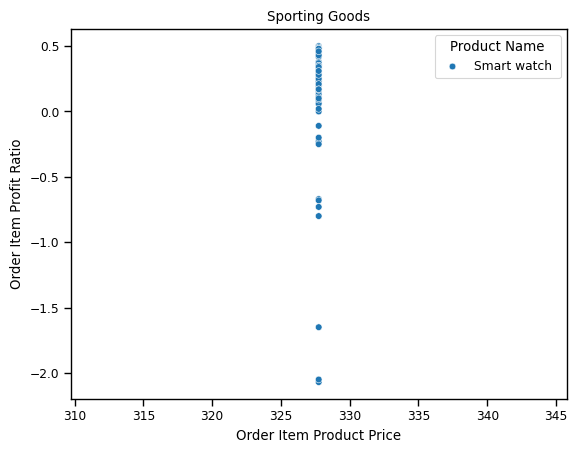

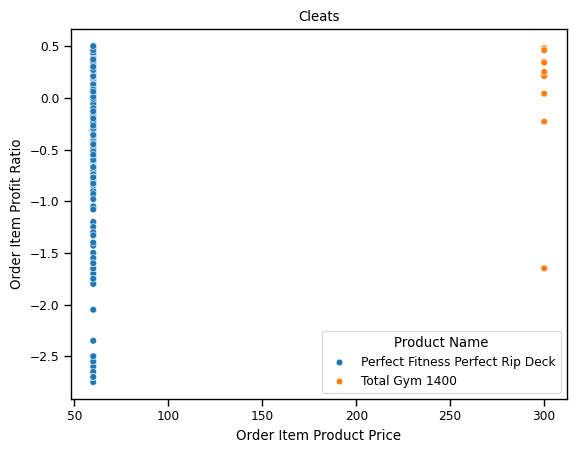

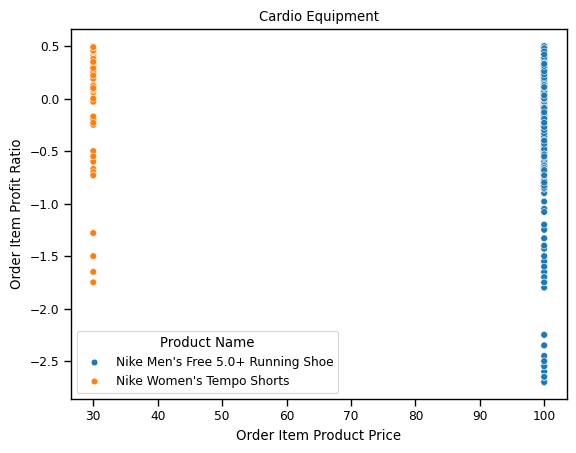

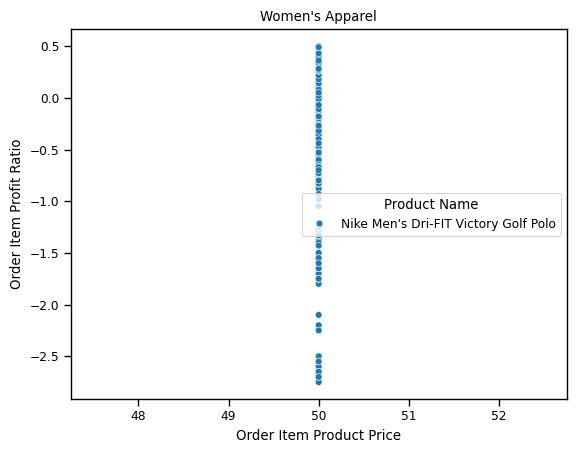

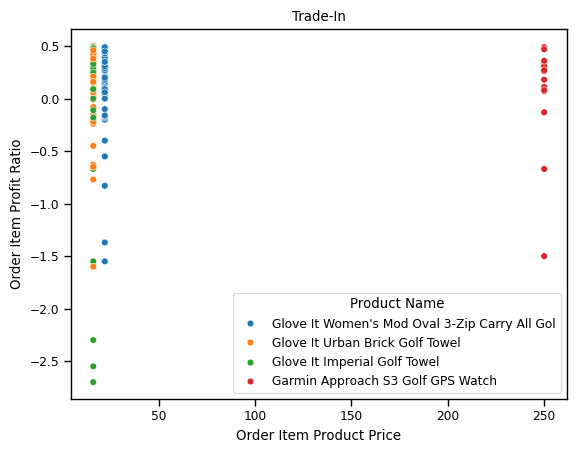

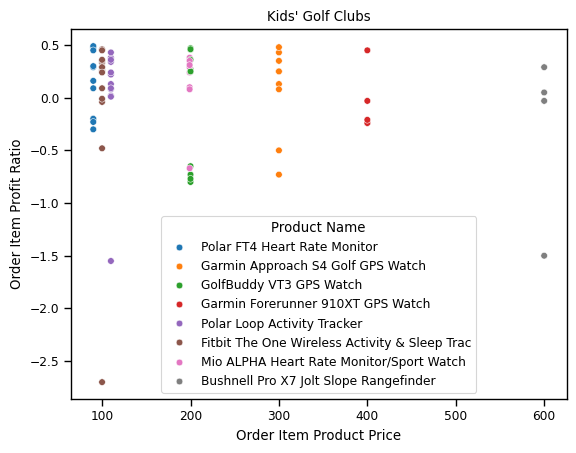

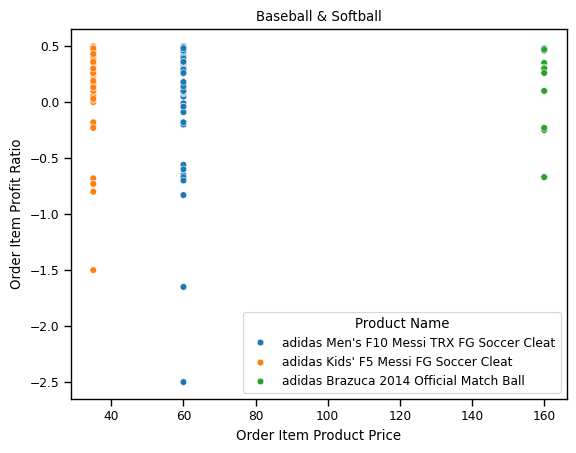

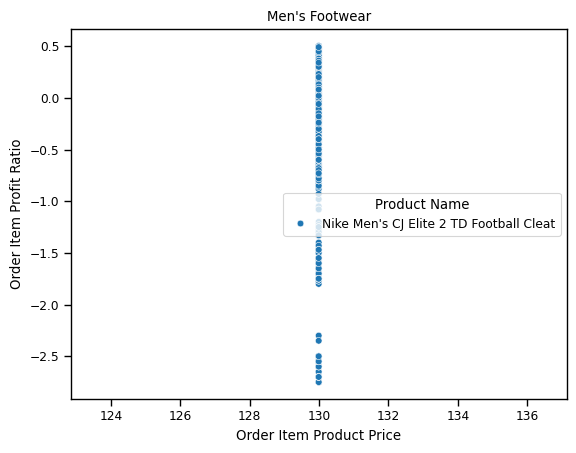

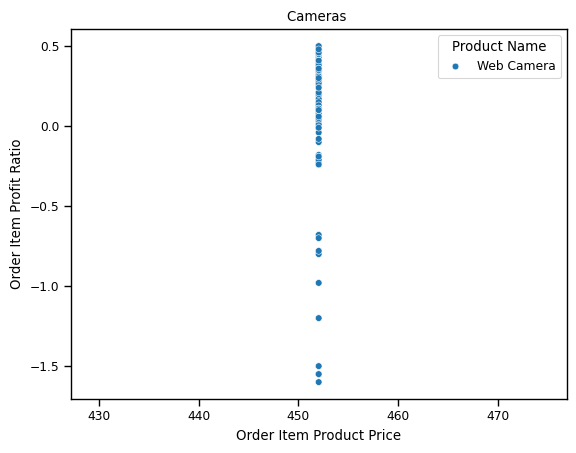

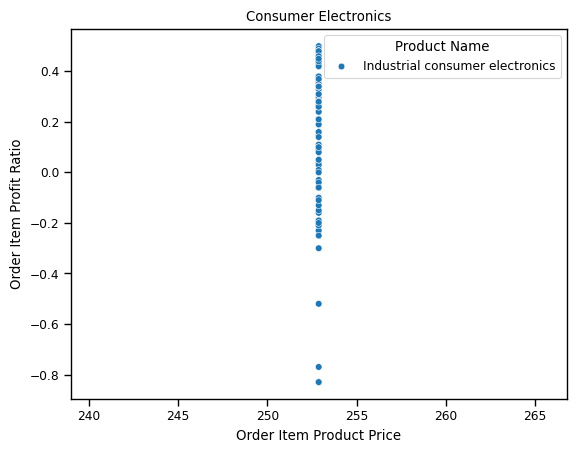

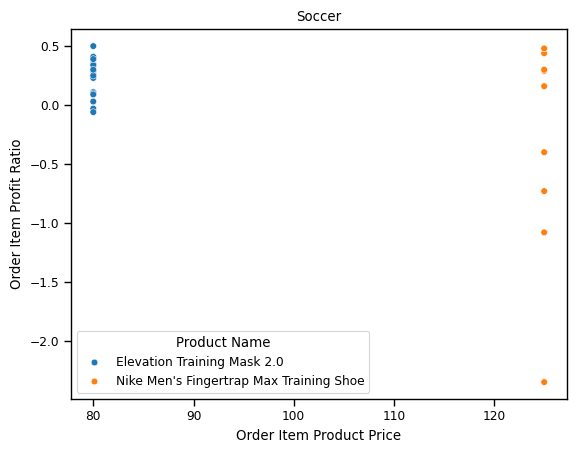

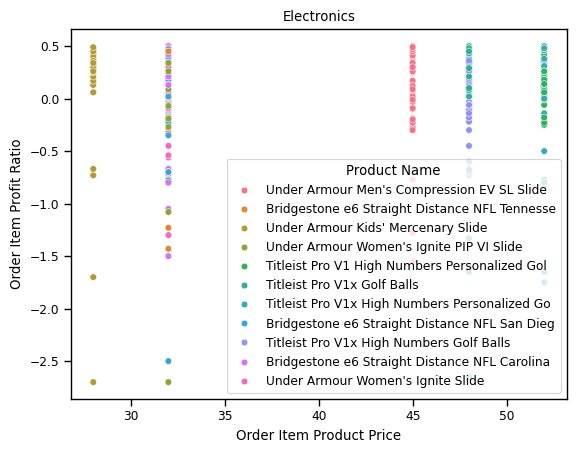

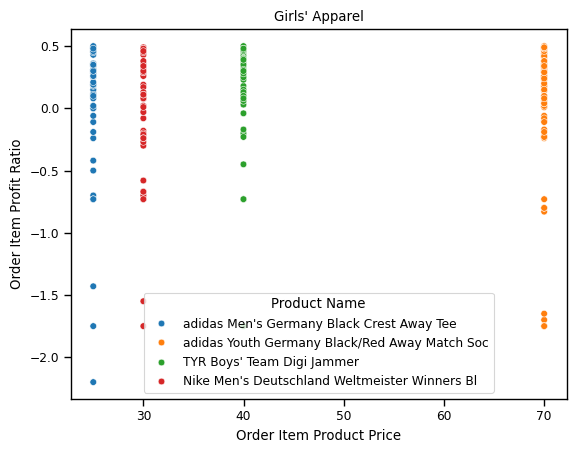

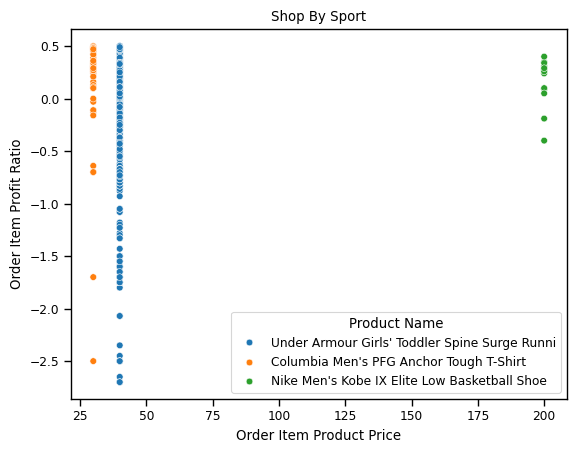

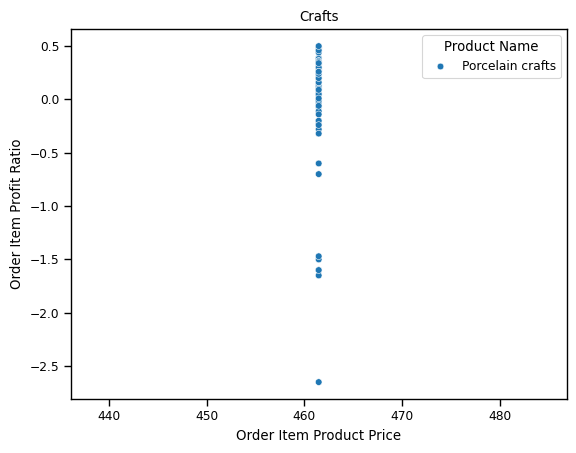

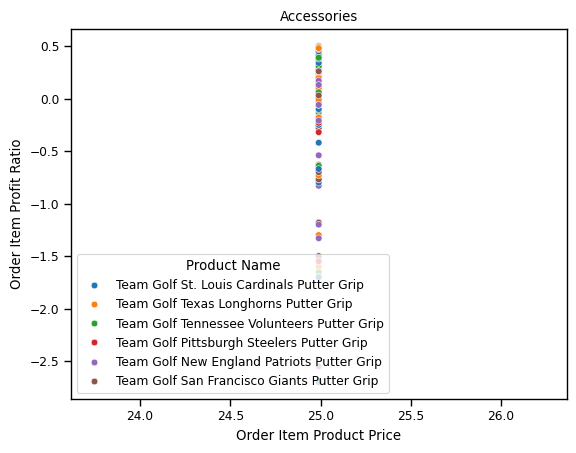

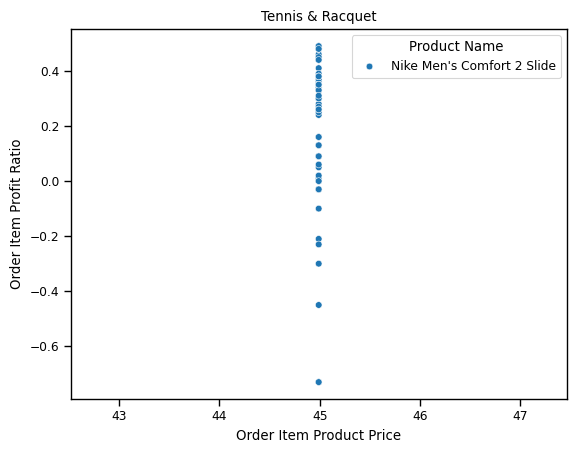

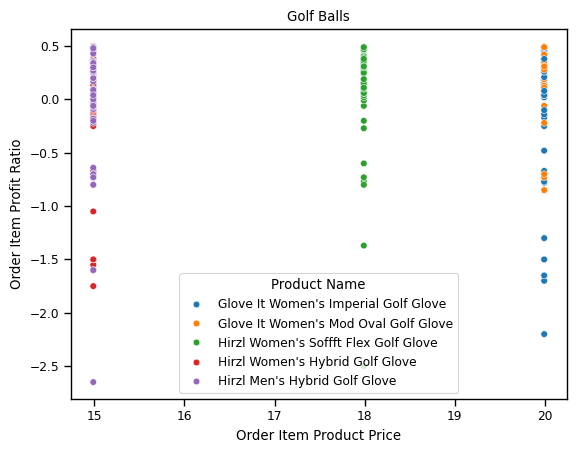

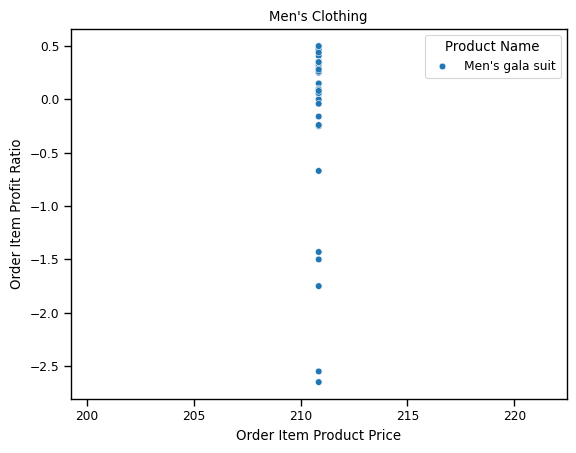

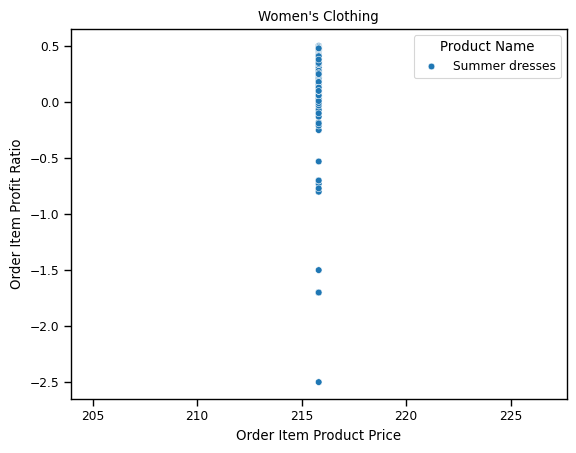

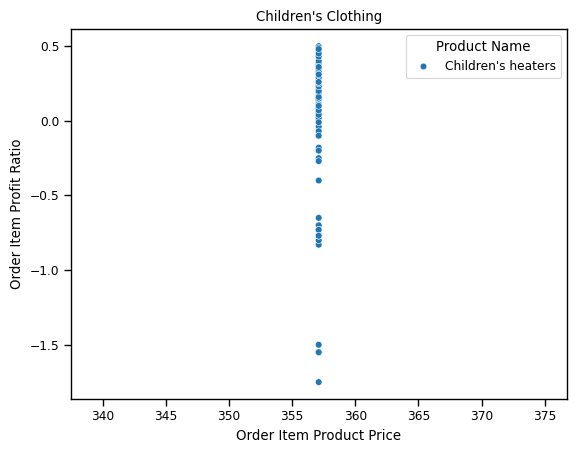

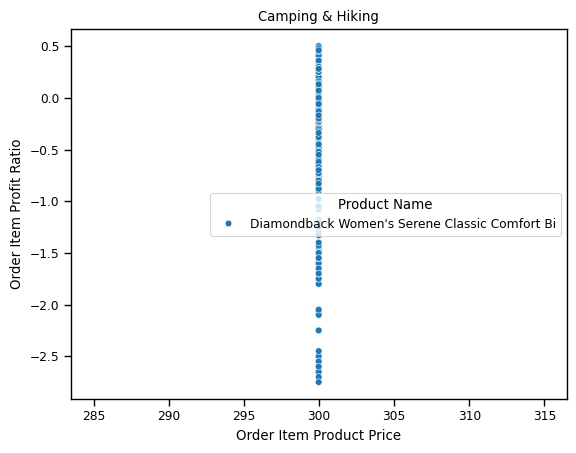

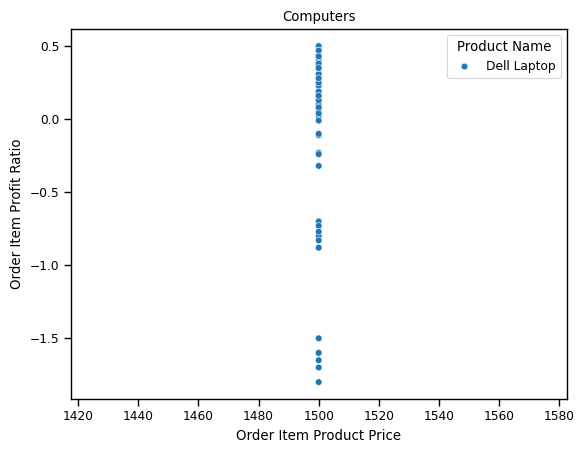

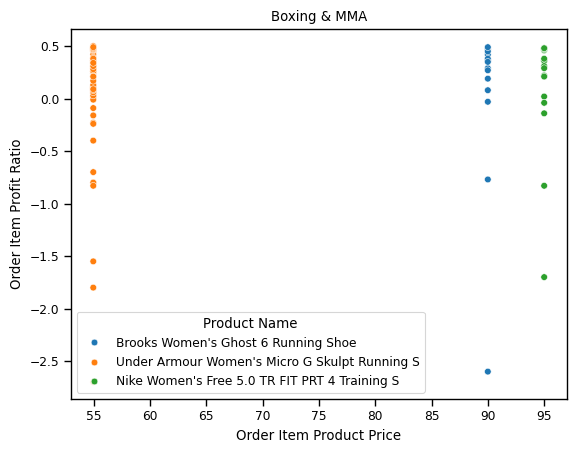

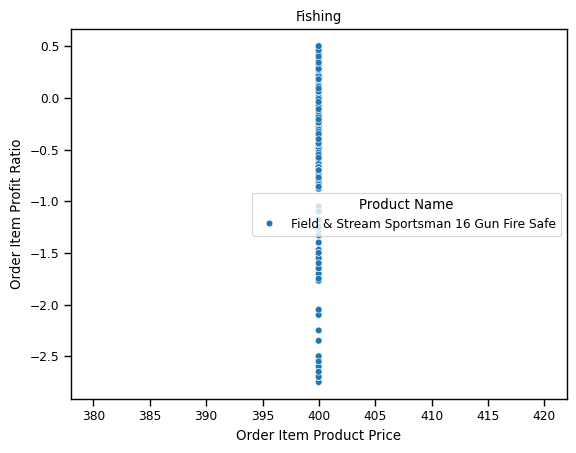

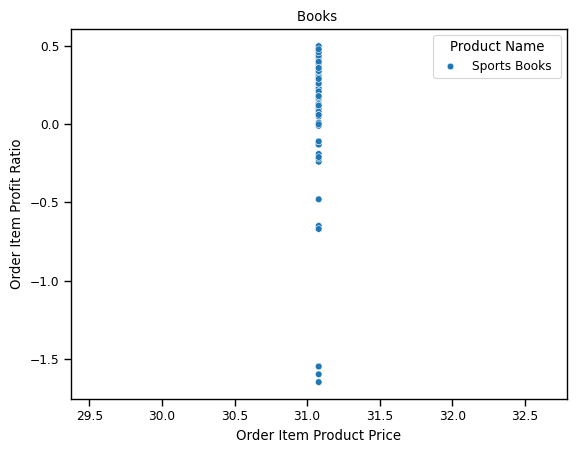

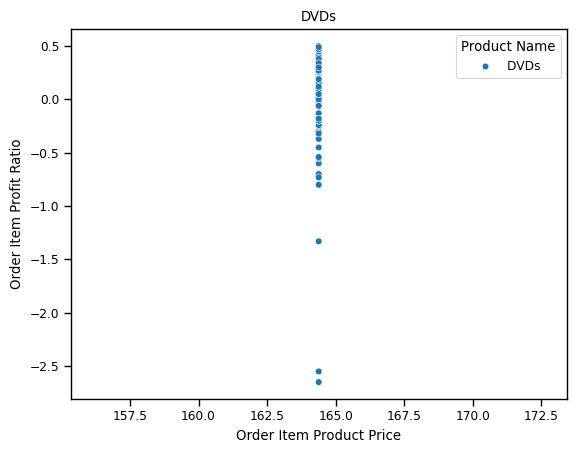

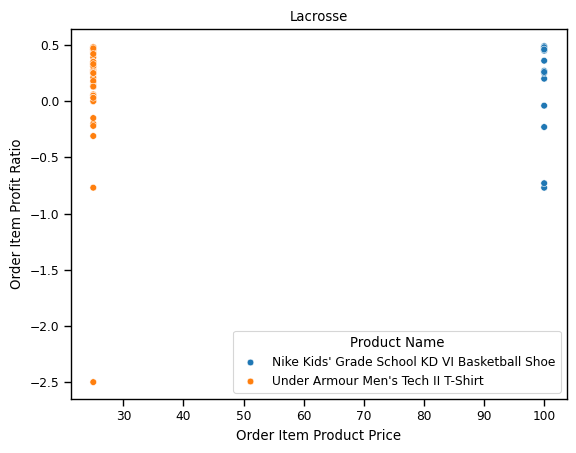

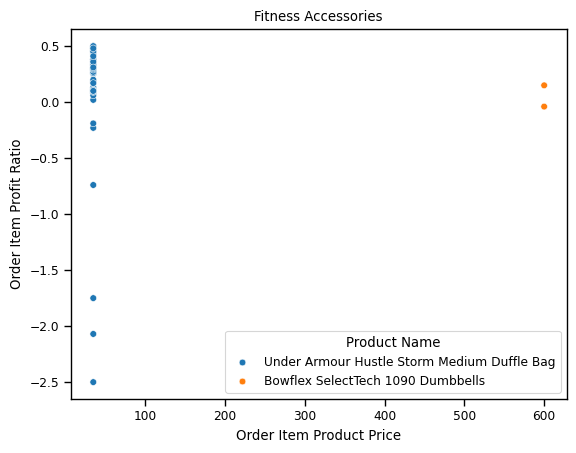

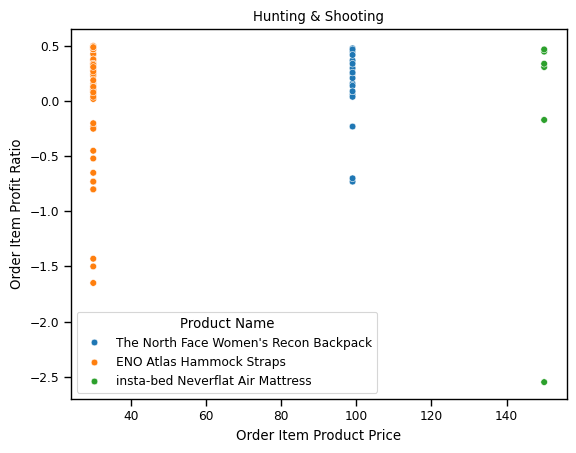

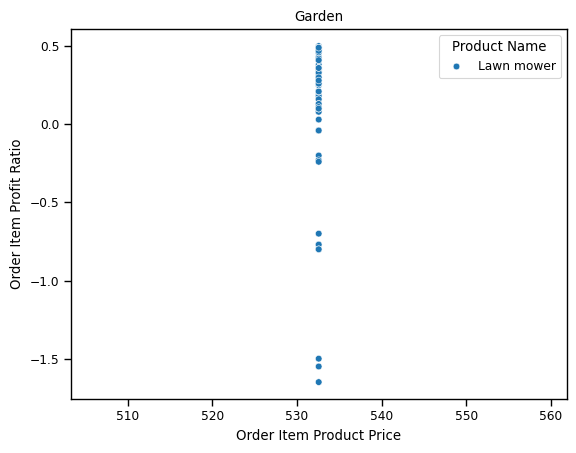

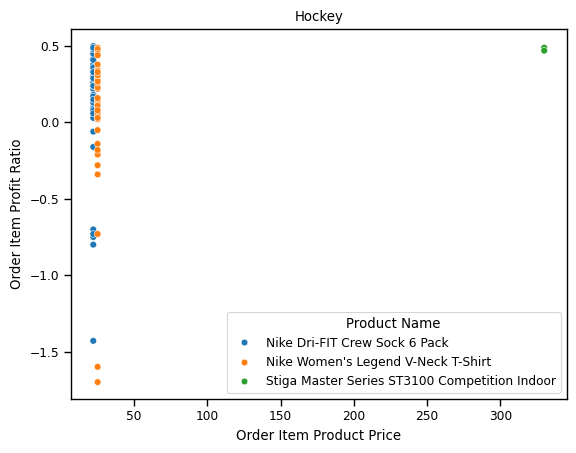

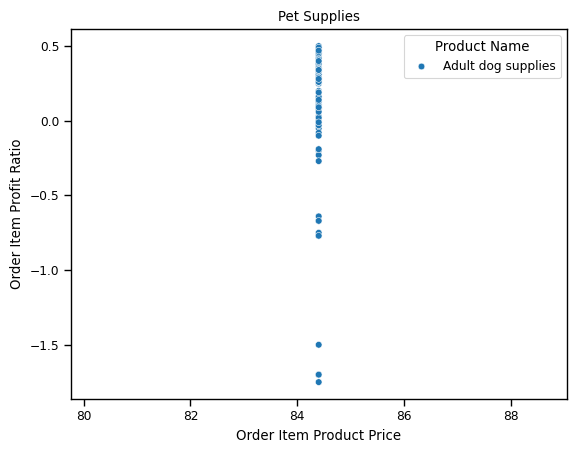

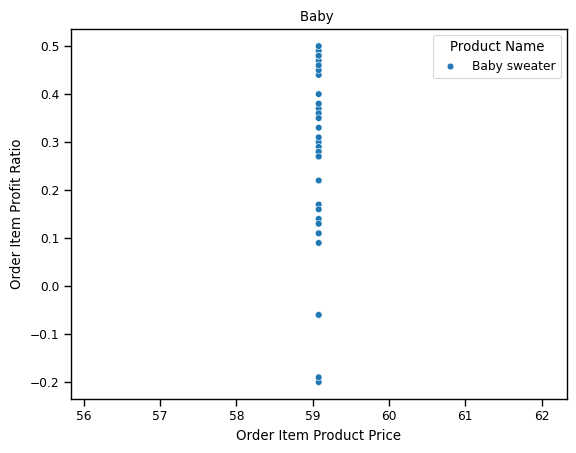

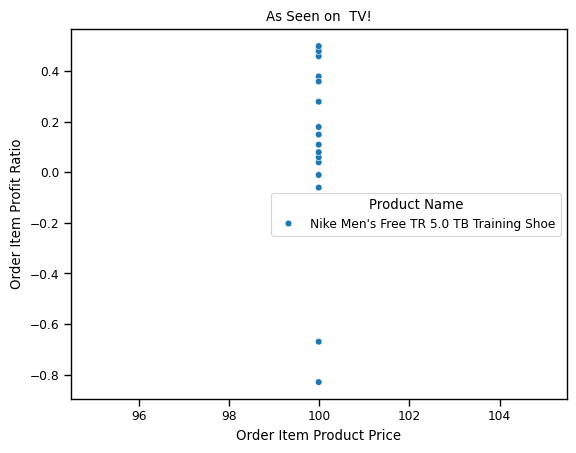

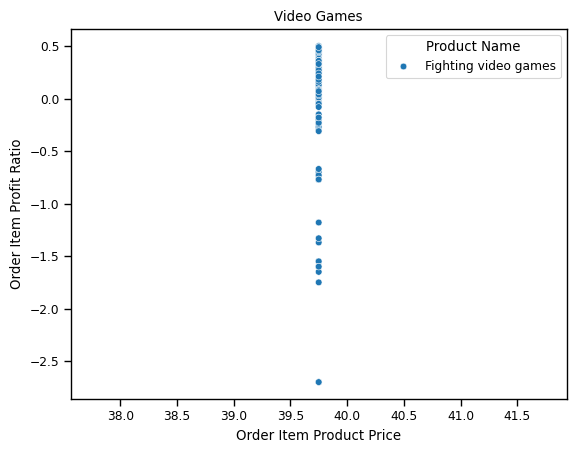

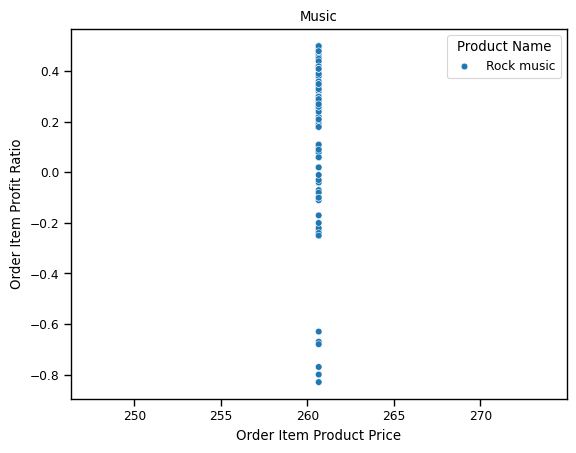

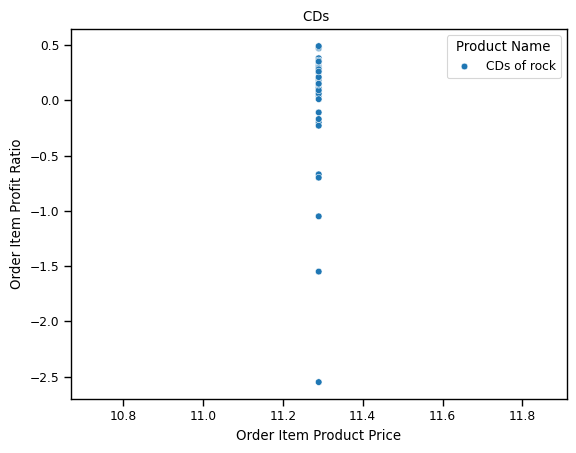

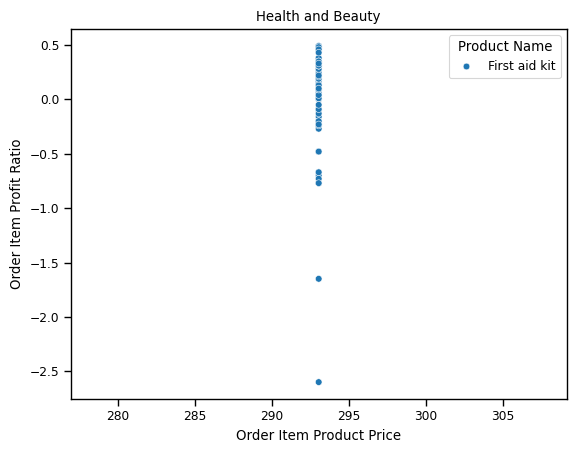

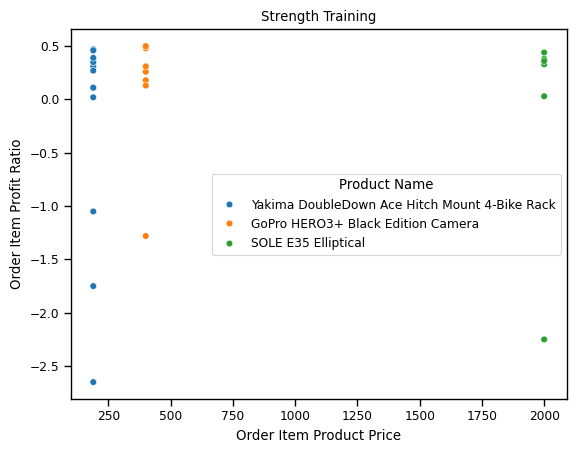

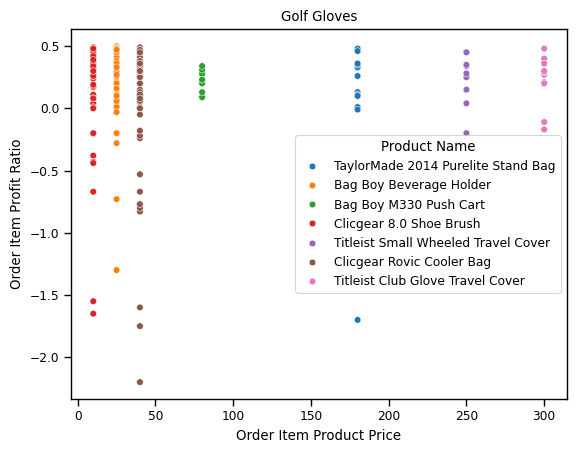

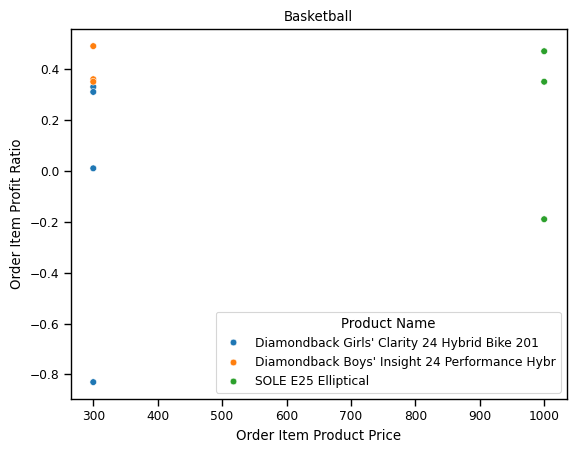

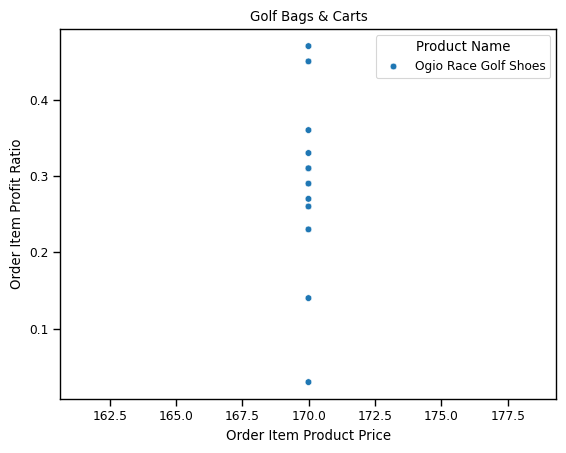

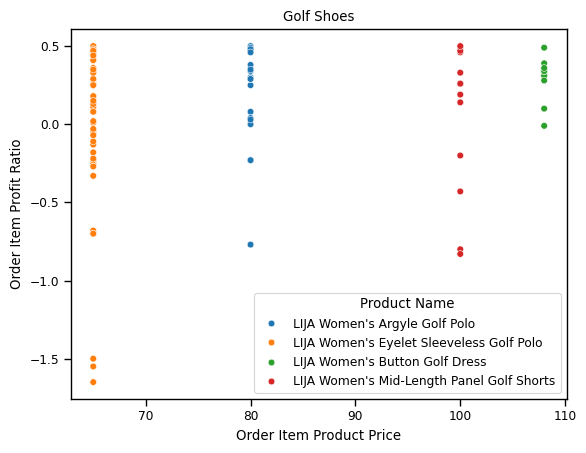

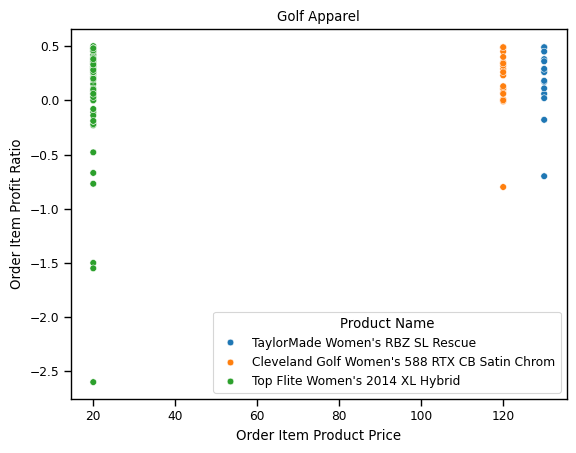

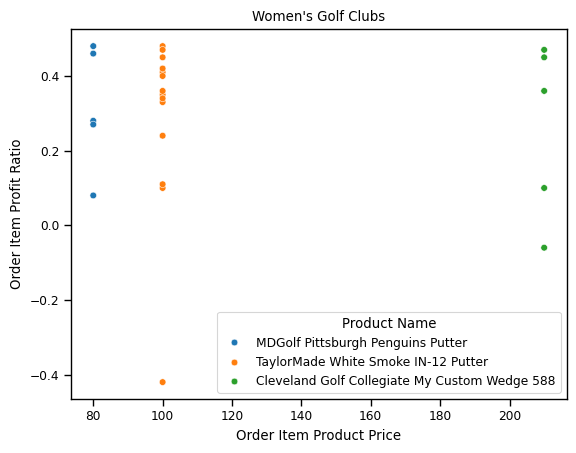

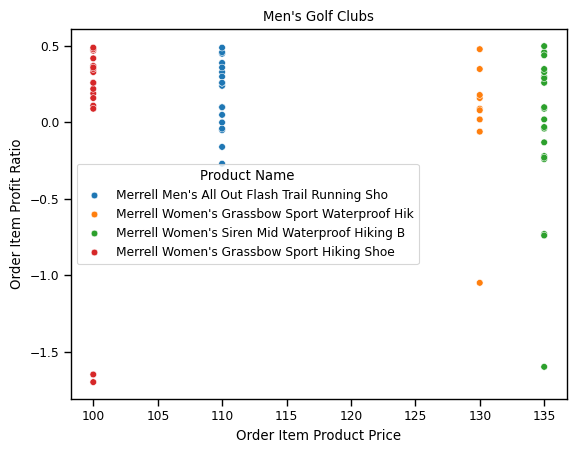

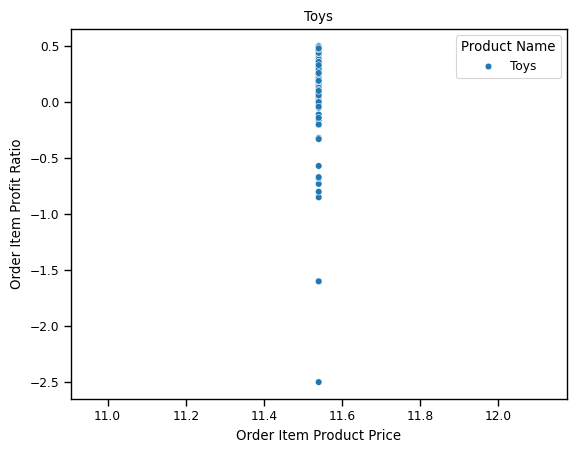

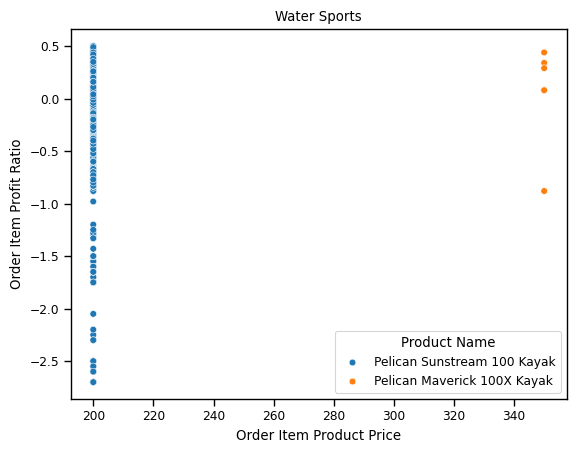

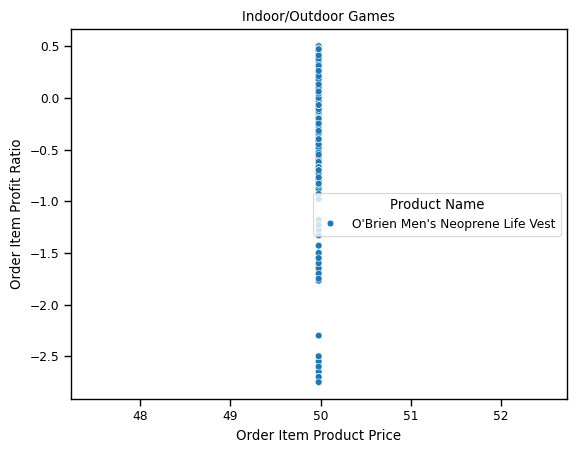

In [24]:
for category in unfi_clean['Category Name'].unique():
    profit_vs_rev=unfi_clean[unfi_clean['Category Name']==category]
    ax=sns.scatterplot(x="Order Item Product Price",y="Order Item Profit Ratio",data=profit_vs_rev,hue='Product Name')
    ax.set_title(category)
    plt.show()


When segregating by product category and by specific product, we can see a scatter distribution of revenue and profits. Many products have more sells on the positive side of profit ratio with a "few" losses, while other items have an uniform spread (they have as much positive as negative profit ratio's) some of these are either bulky (camping/hiking) or seasonal (Water sports , indoor /outdoor games). 

Significant amount of items that have low profit margin ratio. Is this due to:
1. Discounting.
2. High operational costs.
3. Returns.
4. Data issues.
5. Selling at a loss.

# Model building
Going after to answer the question of "Is a delivery a late delivery"?.

## Model choice
Considering this a classification task, where we need to determine if (Yes or No) a given order will fall in the 'late delivery bucket' or not (binary classification). Could be generalized to other 'buckets' such as 'On time', 'In transit', 'Fulfillment stage', etc (multiclass classification). 

I'll apply logistic regression.

In [62]:
#Calling model building suite.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,classification_report

In [28]:
#preparing data to accommodate model.
print(unfi_clean.columns)
unfi_clean.describe()

Index(['Type', 'Days for shipping (real)', 'Benefit per order',
       'Sales per customer', 'Delivery Status', 'Category Id', 'Category Name',
       'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname',
       'Customer Id', 'Customer Lname', 'Customer Password',
       'Customer Segment', 'Customer State', 'Customer Street',
       'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order City', 'Order Country',
       'Order Customer Id', 'order date (DateOrders)', 'Order Id',
       'Order Item Cardprod Id', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order State', 'Order Status', 'Product Card Id', 'Product Category Id',
       'Product Name', 'Product Price', 'Product Status',
       'shipping date (DateOrders)', 'S

,Days for shipping (real),Benefit per order,Sales per customer,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,Longitude,Order Customer Id,...,Sales,Order Item Total,Order Profit Per Order,Product Card Id,Product Category Id,Product Price,Product Status,shipping date (DateOrders),Month of Order,Year of Order
count,40587.0,40587.000000,40587.000000,40587.000000,40587.000000,40587.000000,40587.000000,40587.000000,40587.000000,40587.000000,...,40587.000000,40587.000000,40587.000000,40587.000000,40587.000000,40587.000000,40587.0,40587,40587.000000,40587.000000
mean,3.496637,21.614943,183.233387,31.842733,6729.213862,35784.710646,5.440363,29.677085,-84.843334,6729.213862,...,203.935142,183.233387,21.614943,692.061325,31.842733,141.519479,0.0,2016-06-17 18:09:39.946780928,6.236036,2015.975189
min,0.0,-4274.979980,7.490000,2.000000,1.000000,603.000000,2.000000,-33.937553,-158.025986,1.000000,...,9.990000,7.490000,-4274.979980,19.000000,2.000000,9.990000,0.0,2015-01-03 03:30:00,1.000000,2015.000000
25%,2.0,7.180000,103.989998,18.000000,3278.000000,725.000000,4.000000,18.265404,-98.243797,3278.000000,...,119.980003,103.989998,7.180000,403.000000,18.000000,50.000000,0.0,2015-09-27 22:08:00,3.000000,2015.000000
50%,3.0,31.430000,163.990005,29.000000,6514.000000,19148.000000,5.000000,33.082829,-76.772842,6514.000000,...,199.919998,163.990005,31.430000,627.000000,29.000000,65.000000,0.0,2016-06-16 19:55:00,6.000000,2016.000000
75%,5.0,64.754997,248.960007,45.000000,9819.000000,78040.000000,7.000000,39.277561,-66.370583,9819.000000,...,299.950012,248.960007,64.754997,1004.000000,45.000000,199.990005,0.0,2017-03-07 16:24:00,9.000000,2017.000000
max,6.0,721.599976,1899.989990,76.000000,20756.000000,99205.000000,12.000000,48.781933,115.263077,20756.000000,...,1999.989990,1899.989990,721.599976,1363.000000,76.000000,1999.989990,0.0,2018-02-06 16:59:00,12.000000,2018.000000
std,1.627726,107.615723,120.746153,15.709018,4180.110937,37481.147802,1.634087,9.820802,21.463808,4180.110937,...,133.102290,120.746153,107.615723,337.163835,15.709018,140.723672,0.0,NaN,3.417127,0.830123


First I would like to take a look at the ranges for the data and see what needs scaling , in addition is a good review of which explanatory variables to include / not include. 
The features I decided to remove are:
1. Latitude/Longitude, as other data already imply location.
2. Customer data, as personal data shouldn't have any association with delays.
3. Order data related to customer, profitability,sales details. These shouldn't have an association with supply chain delays/fulfillment.

So a new dataframe will include the following features :



In [76]:
model_df=unfi_clean[['Type', 'Days for shipping (real)', 
       'Delivery Status', 'Category Id',
       'Customer Segment', 'Customer State','Department Name','Market', 'Order City', 'Order Country',
       'order date (DateOrders)','Order Item Id', 'Order Item Quantity','Order Item Total', 'Order Region',
       'Order State', 'Order Status', 'Product Card Id','Product Name', 'Product Status',
       'shipping date (DateOrders)', 'Shipping Mode']]

How much encoding is needed? Numerical and categorical features.

In [33]:
for columns in model_df.columns:
    print(columns,model_df[columns].unique())

Type ['CASH' 'PAYMENT' 'TRANSFER' 'DEBIT']
Days for shipping (real) <IntegerArray>
[4, 2, 3, 6, 0, 5, 1]
Length: 7, dtype: Int64
Delivery Status ['Shipping on time' 'Advance shipping' 'Late delivery' 'Shipping canceled']
Category Id [73 17  9 24 41 38  3 18 62 65  2 13 26 29 66 40 37  6 36 70 76 63 43 64
 12 45 59 67  5 11 44 68  7 72 60 16 75 71 61 69 10 35  4 34 33 32 31 30
 74 48 46]
Customer Segment ['Consumer' 'Corporate' 'Home Office']
Customer State ['CA' 'PR' 'FL' 'IL' 'MT' 'PA' 'TX' 'MD' 'NJ' 'AZ' 'MN' 'NY' 'NM' 'OR'
 'SC' 'UT' 'WV' 'CT' 'MA' 'GA' 'MO' 'TN' 'NC' 'IN' 'VA' 'OH' 'HI' 'NV'
 'DE' 'LA' 'MI' 'CO' 'WA' 'RI' 'DC' 'WI' 'KY' 'ND' 'OK' 'KS' 'AL' 'ID'
 'IA' 'AR']
Department Name ['Fitness' 'Apparel' 'Footwear' 'Golf' 'Outdoors' 'Technology' 'Fan Shop'
 'Book Shop' 'Discs Shop' 'Pet Shop' 'Health and Beauty ']
Market ['Pacific Asia' 'USCA' 'Europe' 'LATAM' 'Africa']
Order City ['Bikaner' 'Townsville' 'Guangzhou' ... 'Zaoyang' 'Huangshi' 'Kwangju']
Order Country ['India' 'A

Shipping date and order date is collapsed in 'Days for shipping column'. I can drop the date columns.
While product status is filled with zero's , I didn't notice this one before!

In [77]:
model_df.drop(['shipping date (DateOrders)','order date (DateOrders)','Product Status','Order Item Total'],axis=1)

,Type,Days for shipping (real),Delivery Status,Category Id,Customer Segment,Customer State,Department Name,Market,Order City,Order Country,Order Item Id,Order Item Quantity,Order Region,Order State,Order Status,Product Card Id,Product Name,Shipping Mode
0,CASH,4,Shipping on time,73,Consumer,CA,Fitness,Pacific Asia,Bikaner,India,179253,1,South Asia,Rajastán,CLOSED,1360,Smart watch,Standard Class
1,PAYMENT,2,Advance shipping,73,Corporate,PR,Fitness,Pacific Asia,Townsville,Australia,179251,1,Oceania,Queensland,PENDING_PAYMENT,1360,Smart watch,Standard Class
2,TRANSFER,2,Late delivery,73,Corporate,FL,Fitness,Pacific Asia,Guangzhou,China,179248,1,Eastern Asia,Guangdong,PROCESSING,1360,Smart watch,First Class
3,CASH,3,Late delivery,73,Corporate,PR,Fitness,Pacific Asia,Guangzhou,China,179247,1,Eastern Asia,Guangdong,CLOSED,1360,Smart watch,Second Class
4,TRANSFER,6,Shipping canceled,73,Corporate,PR,Fitness,Pacific Asia,Tokio,Japón,179245,1,Eastern Asia,Tokio,SUSPECTED_FRAUD,1360,Smart watch,Second Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40582,PAYMENT,2,Advance shipping,45,Home Office,CA,Fan Shop,Pacific Asia,Rockhampton,Australia,65267,1,Oceania,Queensland,PENDING_PAYMENT,1004,Field & Stream Sportsman 16 Gun Fire Safe,Standard Class
40583,PAYMENT,2,Advance shipping,45,Home Office,CA,Fan Shop,Pacific Asia,Rockhampton,Australia,65266,1,Oceania,Queensland,PENDING_PAYMENT,1004,Field & Stream Sportsman 16 Gun Fire Safe,Standard Class
40584,CASH,3,Advance shipping,45,Corporate,PR,Fan Shop,Pacific Asia,Canberra,Australia,65258,1,Oceania,Territorio de la Capital Australiana,CLOSED,1004,Field & Stream Sportsman 16 Gun Fire Safe,Standard Class
40585,PAYMENT,3,Advance shipping,45,Corporate,PR,Fan Shop,Pacific Asia,Guangshui,China,65201,1,Eastern Asia,Hubei,PENDING_PAYMENT,1004,Field & Stream Sportsman 16 Gun Fire Safe,Standard Class


I think this is a good starting point for transformation of the many categories.

In [78]:
# Delivery status as binary...
model_df['DeliverySt']=0
model_df.loc[model_df['Delivery Status']=='Late delivery','DeliverySt']=1
model_df.drop('Delivery Status',axis=1)
# Feeding categorical variables to onehotencoder.
cat_features=['Type','Customer Segment','Customer State','Department Name','Market','Order City','Order Country','Order Region','Order State','Order Status','Product Name','Shipping Mode']
num_features=['Days for shipping (real)','Category Id','Order Item Id','Order Item Quantity','Product Card Id']
y=model_df['DeliverySt']
x=model_df.drop('DeliverySt',axis=1)
X_train,x_test,Y_train,y_test=train_test_split(x,y,test_size=30,random_state=40)

#instations for pipeline

tranxform=ColumnTransformer(transformers=[('numerical',StandardScaler(),num_features),('categorical',OneHotEncoder(),cat_features)])
model=Pipeline(steps=[('Preprocessor',tranxform),('Classifier',LogisticRegression(max_iter=100))])
model.fit(X_train,Y_train)
y_pred=model.predict(x_test)
print("Simple accuracy:",accuracy_score(y_test,y_pred))

C:\Users\nmartinez\AppData\Local\Temp\ipykernel_16044\3981784789.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df['DeliverySt']=0


0        0
1        0
2        1
3        1
4        0
        ..
40582    0
40583    0
40584    0
40585    0
40586    0
Name: DeliverySt, Length: 40587, dtype: int64

1.0


The accuracy score is "perfect", so let's take a look at other metrics to assess how good is this model.

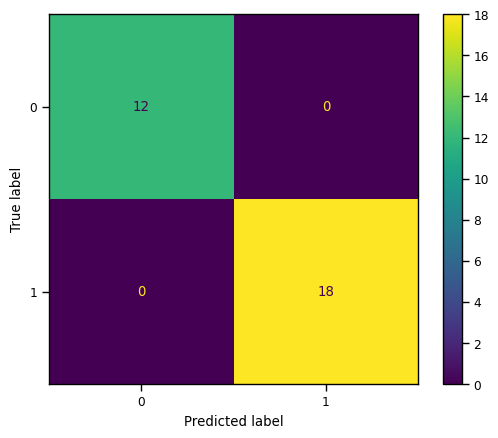

In [81]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
model_df_confusion=confusion_matrix(y_test,y_pred)
model_df_md=ConfusionMatrixDisplay(model_df_confusion,display_labels=model.classes_)
model_df_md.plot()
plt.show()

So the main diagonal show excellent performance of the model. Of course the data was ablated , ie everything not a late delivery was clumped into 1/0's.
Wonder if for demonstration is enough :-D. 